# 7. Comparaciones estadísticas e interpretabilidad

Las comparaciones son pareadas porque todos los modelos predicen exactamente las mismas observaciones de prueba. `run_statistical_tests.py` compara el mejor AUC contra sus alternativas dentro de cada entorno y también contrasta las seis familias de modelos entre scikit-learn y PySpark. Se aplican DeLong a las puntuaciones continuas, McNemar exacta a las decisiones y bootstrap pareado a las diferencias de AUC. La corrección de Holm se aplica por separado a cada familia de pruebas. El bootstrap usa 100 réplicas sobre todas las observaciones; su resolución es limitada y se interpreta junto con los intervalos de confianza.

DeLong pregunta si dos modelos asignan puntuaciones con una capacidad de ordenamiento distinta en los mismos préstamos. McNemar se fija en las decisiones al umbral usado y cuenta en qué casos solo uno de los modelos acierta. El bootstrap remuestrea en pareja las filas de prueba para estimar un intervalo de la diferencia entre AUC. Holm ajusta los p-valores cuando se hacen varias comparaciones y así reduce falsos hallazgos por multiplicidad.

In [1]:
from pathlib import Path
import pandas as pd

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
STATS_DIR = PROJECT_DIR / 'results' / 'estadisticas'
for name in ['sklearn', 'spark']:
    file = STATS_DIR / f'comparaciones_{name}.csv'
    if file.exists():
        print(name)
        table = pd.read_csv(file).sort_values('delong_holm_p_value')
        table = table.rename(columns={
            'model_1': 'Mejor modelo', 'model_2': 'Alternativa',
            'delong_delta_auc': 'Δ AUC', 'delong_holm_p_value': 'p DeLong (Holm)',
            'mcnemar_holm_p_value': 'p McNemar (Holm)',
            'bootstrap_ci95_low': 'IC bootstrap 95 % inferior',
            'bootstrap_ci95_high': 'IC bootstrap 95 % superior',
            'bootstrap_holm_p_value': 'p bootstrap (Holm)',
        })
        shown = table[[
            'Mejor modelo', 'Alternativa', 'Δ AUC', 'p DeLong (Holm)',
            'p McNemar (Holm)', 'IC bootstrap 95 % inferior',
            'IC bootstrap 95 % superior', 'p bootstrap (Holm)',
        ]].round(5)
        p_columns = ['p DeLong (Holm)', 'p McNemar (Holm)', 'p bootstrap (Holm)']
        for column in p_columns:
            shown[column] = shown[column].map(
                lambda value: '<1e-5' if pd.notna(value) and value < 1e-5 else f'{value:.5f}'
            )
        display(shown)

sklearn


,Mejor modelo,Alternativa,Δ AUC,p DeLong (Holm),p McNemar (Holm),IC bootstrap 95 % inferior,IC bootstrap 95 % superior,p bootstrap (Holm)
1,hist_gradient_boosting,gaussian_nb,0.04647,<1e-5,<1e-5,0.04432,0.04868,0.09901
2,hist_gradient_boosting,linear_svc,0.23739,<1e-5,<1e-5,0.23247,0.24110,0.09901
0,hist_gradient_boosting,decision_tree,0.00926,<1e-5,<1e-5,0.00842,0.00984,0.09901
4,hist_gradient_boosting,random_forest,0.00527,<1e-5,0.00022,0.00461,0.00589,0.09901
3,hist_gradient_boosting,logistic_regression,0.00339,<1e-5,0.04542,0.00277,0.00407,0.09901


spark


,Mejor modelo,Alternativa,Δ AUC,p DeLong (Holm),p McNemar (Holm),IC bootstrap 95 % inferior,IC bootstrap 95 % superior,p bootstrap (Holm)
0,gradient_boosted_tree,decision_tree,0.21884,<1e-5,<1e-5,0.21414,0.22166,0.09901
1,gradient_boosted_tree,linear_svc,0.08260,<1e-5,<1e-5,0.07965,0.08479,0.09901
3,gradient_boosted_tree,naive_bayes,0.18721,<1e-5,<1e-5,0.18289,0.19075,0.09901
4,gradient_boosted_tree,random_forest,0.00599,<1e-5,0.02264,0.00544,0.00673,0.09901
2,gradient_boosted_tree,logistic_regression,0.00287,<1e-5,0.17243,0.00228,0.00356,0.09901


En scikit-learn, HistGradientBoosting presenta el mayor AUC y DeLong con Holm distingue su puntuación de cada alternativa, incluida regresión logística (diferencia de 0,00339). McNemar también encuentra diferencia en las decisiones frente a regresión logística, aunque es cercana al límite de 0,05 (p ajustado 0,04542). En PySpark, GBT es el mejor por AUC; DeLong lo separa de sus alternativas, pero McNemar no distingue sus decisiones de las de regresión logística (p ajustado 0,17243). Los intervalos bootstrap sin ajustar no incluyen cero, pero los p-valores bootstrap corregidos son 0,09901 en las dos familias. Con solo 100 réplicas, la resolución del bootstrap no alcanza para declarar significación tras Holm. Estas tablas comparan al modelo líder con cada alternativa; no son una prueba de todas las parejas posibles.

## 7.1 Comparación entre entornos

La tabla siguiente compara implementaciones de la misma familia sobre idénticas filas de prueba. `Δ AUC` se define como AUC de scikit-learn menos AUC de PySpark: un valor positivo favorece scikit-learn. Los valores ajustados de Holm permiten identificar diferencias estadísticas sin ignorar que se hicieron seis comparaciones.

In [2]:
cross_file = STATS_DIR / 'comparaciones_entornos.csv'
if cross_file.exists():
    cross = pd.read_csv(cross_file).sort_values('delong_holm_p_value')
    cross_table = cross.rename(columns={
        'familia_modelo': 'Familia de modelo',
        'delong_auc_1': 'AUC scikit-learn', 'delong_auc_2': 'AUC PySpark',
        'delong_delta_auc': 'Δ AUC (sklearn − Spark)',
        'delong_holm_p_value': 'p DeLong (Holm)',
        'mcnemar_holm_p_value': 'p McNemar (Holm)',
        'bootstrap_ci95_low': 'IC bootstrap 95 % inferior',
        'bootstrap_ci95_high': 'IC bootstrap 95 % superior',
        'bootstrap_holm_p_value': 'p bootstrap (Holm)',
    })
    shown_cross = cross_table[[
        'Familia de modelo', 'AUC scikit-learn', 'AUC PySpark',
        'Δ AUC (sklearn − Spark)', 'p DeLong (Holm)', 'p McNemar (Holm)',
        'IC bootstrap 95 % inferior', 'IC bootstrap 95 % superior',
        'p bootstrap (Holm)',
    ]].round(5)
    p_columns = ['p DeLong (Holm)', 'p McNemar (Holm)', 'p bootstrap (Holm)']
    for column in p_columns:
        shown_cross[column] = shown_cross[column].map(
            lambda value: '<1e-5' if pd.notna(value) and value < 1e-5 else f'{value:.5f}'
        )
    display(shown_cross)

,Familia de modelo,AUC scikit-learn,AUC PySpark,Δ AUC (sklearn − Spark),p DeLong (Holm),p McNemar (Holm),IC bootstrap 95 % inferior,IC bootstrap 95 % superior,p bootstrap (Holm)
1,Árbol de decisión,0.70398,0.49390,0.21008,<1e-5,1.00000,0.20486,0.21304,0.11881
4,SVM lineal,0.47585,0.63014,-0.15429,<1e-5,1.00000,-0.15892,-0.14960,0.11881
5,Naive Bayes gaussiano,0.66677,0.52553,0.14123,<1e-5,<1e-5,0.13754,0.14420,0.11881
2,Bosque aleatorio,0.70796,0.70675,0.00121,0.00136,1.00000,0.00068,0.00194,0.11881
3,Boosting,0.71324,0.71274,0.00050,0.03398,1.00000,0.00019,0.00094,0.11881
0,Regresión logística,0.70984,0.70988,-0.00003,0.19163,1.00000,-0.00007,0.00001,0.21782


La diferencia de regresión logística entre entornos es −0,00003 y no resulta significativa con DeLong (p ajustado 0,19163). En cambio, DeLong detecta diferencias para árbol (+0,21008 a favor de scikit-learn), SVM lineal (−0,15429, a favor de Spark), Naive Bayes (+0,14123), bosque aleatorio (+0,00121) y boosting (+0,00050). Las diferencias de árbol, SVM y Naive Bayes son grandes en AUC; las de bosque y boosting son muy pequeñas aunque detectables en esta prueba extensa. McNemar solo señala diferencia de decisiones para Naive Bayes tras Holm. Para las seis comparaciones, el bootstrap con 100 réplicas no produce p-valores ajustados menores que 0,05; sus intervalos y valores se leen con la resolución limitada documentada.

La significación estadística no mide por sí sola el valor práctico de la diferencia. Las implementaciones, los grids y el número de folds no son idénticos; una diferencia pequeña puede resultar detectable con una prueba de 269.062 observaciones y, aun así, tener un efecto operativo limitado. McNemar puede discrepar de DeLong porque evalúa clases predichas a un umbral, mientras que DeLong compara el ordenamiento de las puntuaciones.

## 7.2 Interpretabilidad con LIME

La explicación local se genera para `HistGradientBoostingClassifier`, que fue el mejor modelo de scikit-learn por AUC ROC. Se usan 5.000 observaciones como fondo de perturbación de LIME y 800 perturbaciones alrededor de un préstamo con `Charged Off`; este fondo solo sirve para interpretar el modelo y no cambia el entrenamiento.

In [3]:
lime_file = PROJECT_DIR / 'results' / 'lime' / 'explicacion_local_hist_gradient_boosting.csv'
if lime_file.exists():
    lime_table = pd.read_csv(lime_file)
    display(lime_table.head(12))

,feature,weight,abs_weight
0,term= 36 months,-0.064987,0.064987
1,home_ownership=RENT,0.035177,0.035177
2,annual_inc <= 45000.00,0.030010,0.030010
3,fico_range_high > 714.00,-0.029823,0.029823
4,11.86 < dti <= 17.90,-0.027103,0.027103
5,loan_amnt <= 7943.75,-0.024482,0.024482
6,12.85 < int_rate <= 15.99,0.021628,0.021628
7,verification_status=Source Verified,0.020373,0.020373
8,grade=C,0.017573,0.017573
9,purpose=debt_consolidation,0.009839,0.009839


En la tabla, el signo se refiere a la probabilidad local de `Charged Off` para el caso seleccionado: valores positivos la empujan hacia default y valores negativos la alejan. En este préstamo, vivir en arriendo, tener ingreso menor o una tasa más alta aportan peso positivo; un plazo de 36 meses, FICO mayor que 714, DTI moderado y monto menor aportan peso negativo. Son contribuciones del modelo alrededor de este único caso, no efectos causales ni reglas universales. La salida de LIME no mide importancia global y puede variar con el préstamo, el conjunto de referencia y las perturbaciones. En un entorno distribuido se materializa solo el caso y una muestra pequeña; no se explica todo el clúster automáticamente.

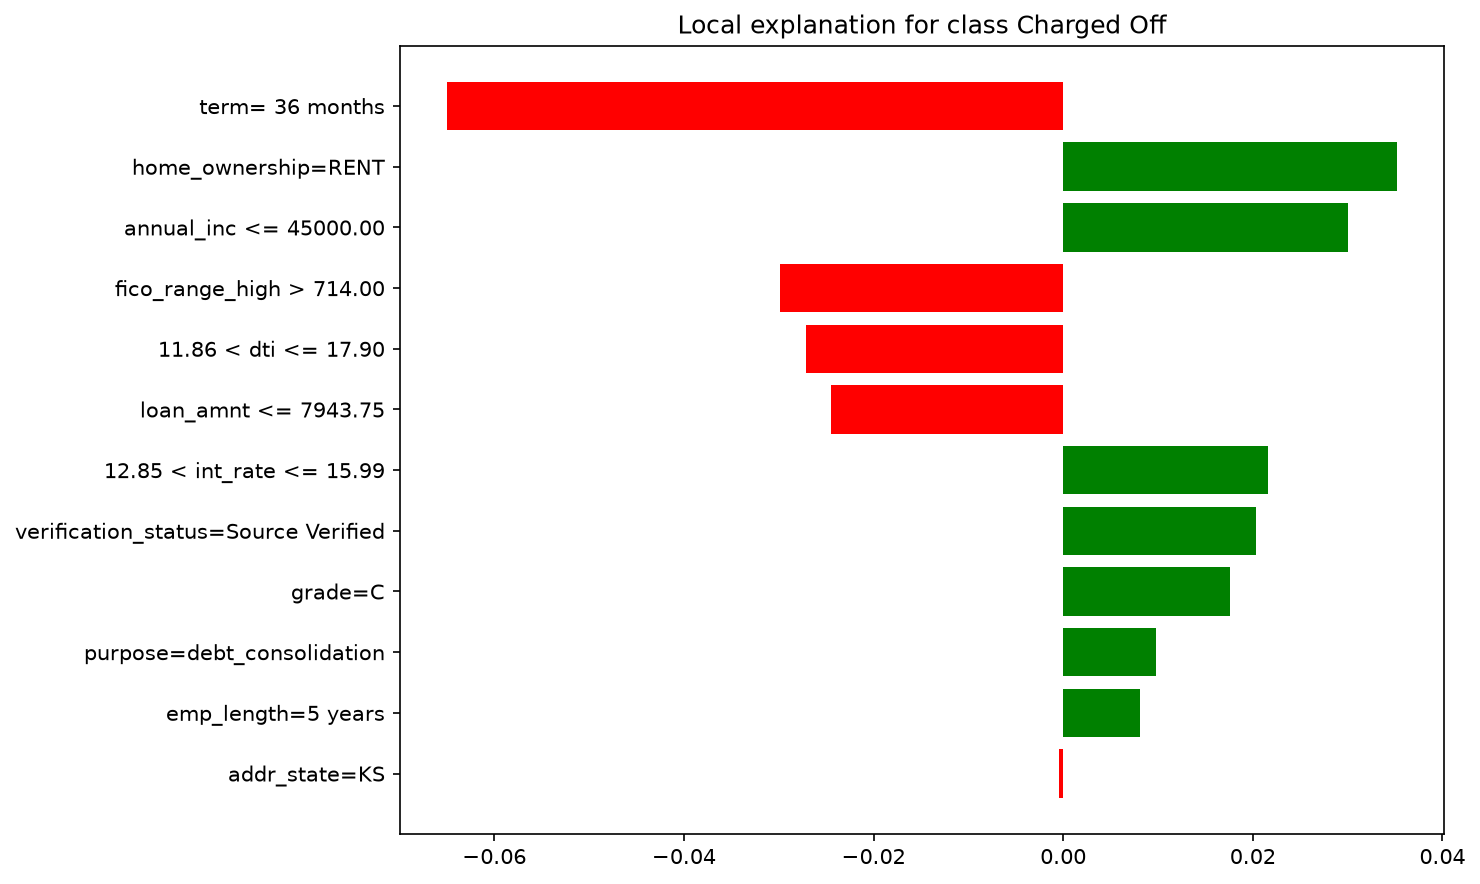

In [4]:
from IPython.display import Image, display
lime_fig = PROJECT_DIR / 'figures' / 'lime' / 'lime_hist_gradient_boosting.png'
if lime_fig.exists(): display(Image(filename=str(lime_fig)))